In [2]:
# ============================
# LOAD CELL (run once per kernel)
# ============================
from pathlib import Path
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

BASE_DIR = Path("/")
LEAGUE_DIR = BASE_DIR / "Data" / "Clean" / "Leagues"

LEAGUE_FILES = {
    "2026_small": LEAGUE_DIR / "2026_small_normalized.csv",
#     "2025_small": LEAGUE_DIR / "2025_small_normalized.csv",
#     "2025_large": LEAGUE_DIR / "2025_large_normalized.csv",
}

def _read_league(path: Path, league_key: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    # standardize/ensure required columns exist (don't silently invent data)
    required = ["season", "league_id", "event_name", "event_date", "event_key", "event_id",
                "entry_id", "username", "player_name", "dg_id", "raw_winnings"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{path.name} missing columns: {missing}")

    # types
    df["league_key"] = league_key

    # dates
    df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce")

    # ids + numeric
    df["season"] = pd.to_numeric(df["season"], errors="coerce").astype("Int64")
    df["event_id"] = pd.to_numeric(df["event_id"], errors="coerce").astype("Int64")
    df["dg_id"] = pd.to_numeric(df["dg_id"], errors="coerce").astype("Int64")
    df["raw_winnings"] = pd.to_numeric(df["raw_winnings"], errors="coerce")

    # clean strings
    for c in ["league_id", "event_name", "event_key", "entry_id", "username", "player_name"]:
        df[c] = df[c].astype(str).str.strip()

    return df

# Load all leagues
league_dfs = {k: _read_league(p, k) for k, p in LEAGUE_FILES.items()}
leagues_all = pd.concat(league_dfs.values(), ignore_index=True)

# Convenience views
# leagues_2024 = leagues_all[leagues_all["season"] == 2024].copy()
leagues_2026 = leagues_all[leagues_all["season"] == 2026].copy()

# Quick sanity
print("Loaded league files:", ", ".join(league_dfs.keys()))
print("Total rows:", len(leagues_all))
print("Rows by league_key:\n", leagues_all["league_key"].value_counts().to_string())
print("Rows by season:\n", leagues_all["season"].value_counts(dropna=False).to_string())
print("Missing event_id rows:", int(leagues_all["event_id"].isna().sum()))
print("Missing dg_id rows:", int(leagues_all["dg_id"].isna().sum()))

ValueError: 2026_small_normalized.csv missing columns: ['season', 'league_id', 'event_name', 'event_date', 'event_key', 'event_id', 'entry_id', 'player_name', 'dg_id', 'raw_winnings']

In [61]:
# ============================
# OWNERSHIP PRIMITIVES
# ============================

# Event key we will consistently use
# (league_key matters because ownership differs by league)
event_cols = [
    "league_key",
    "season",
    "event_id",
    "event_name",
    "event_date",
]

# Count picks per player per event per league
ownership = (
    leagues_all
    .groupby(event_cols + ["dg_id", "player_name"], dropna=False)
    .size()
    .reset_index(name="pick_count")
)

# Total entries per event per league
event_totals = (
    leagues_all
    .groupby(event_cols, dropna=False)
    .size()
    .reset_index(name="field_size")
)

# Merge totals and compute ownership %
ownership = ownership.merge(
    event_totals,
    on=event_cols,
    how="left",
)

ownership["ownership_pct"] = ownership["pick_count"] / ownership["field_size"]

# Convenience flags
ownership["is_chalk"] = (
    ownership["ownership_pct"]
    == ownership.groupby(event_cols)["ownership_pct"].transform("max")
)

# Sort for inspection
ownership = ownership.sort_values(
    ["league_key", "event_date", "ownership_pct"],
    ascending=[True, True, False],
).reset_index(drop=True)

# ----------------------------
# Sanity checks
# ----------------------------
print("Ownership rows:", len(ownership))
print("Events covered:", ownership[event_cols].drop_duplicates().shape[0])
print("Ownership sums (should be 1.0):")
display(
    ownership
    .groupby(event_cols)["ownership_pct"]
    .sum()
    .round(6)
    .value_counts()
    .head()
)

ownership.head(20)

Ownership rows: 2807
Events covered: 93
Ownership sums (should be 1.0):


ownership_pct
1.0    93
Name: count, dtype: int64

,league_key,season,event_id,event_name,event_date,dg_id,player_name,pick_count,field_size,ownership_pct,is_chalk
0,2024_small,2024,11,Sony Open in Hawaii,2024-01-11,17576,Corey Conners,11,49,0.224490,True
1,2024_small,2024,11,Sony Open in Hawaii,2024-01-11,12423,Chris Kirk,9,49,0.183673,False
2,2024_small,2024,11,Sony Open in Hawaii,2024-01-11,14578,Russell Henley,9,49,0.183673,False
3,2024_small,2024,11,Sony Open in Hawaii,2024-01-11,8825,Brian Harman,4,49,0.081633,False
4,2024_small,2024,11,Sony Open in Hawaii,2024-01-11,23950,Ludvig Aberg,3,49,0.061224,False
5,2024_small,2024,11,Sony Open in Hawaii,2024-01-11,13997,Adam Svensson,2,49,0.040816,False
6,2024_small,2024,11,Sony Open in Hawaii,2024-01-11,14609,Si Woo Kim,2,49,0.040816,False
7,2024_small,2024,11,Sony Open in Hawaii,2024-01-11,14796,Tyrrell Hatton,2,49,0.040816,False
8,2024_small,2024,11,Sony Open in Hawaii,2024-01-11,21554,J.T. Poston,2,49,0.040816,False
9,2024_small,2024,11,Sony Open in Hawaii,2024-01-11,21756,Eric Cole,2,49,0.040816,False


In [64]:
# ============================
# CHALK CONCENTRATION METRICS
# ============================

def gini(x: np.ndarray) -> float:
    if np.all(x == 0):
        return 0.0
    x = np.sort(x)
    n = len(x)
    cumx = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n

chalk_metrics = (
    ownership
    .groupby(
        ["league_key", "season", "event_id", "event_name", "event_date"],
        as_index=False
    )
    .apply(lambda d: pd.Series({
        "top1_ownership": d["ownership_pct"].max(),
        "top3_ownership": d["ownership_pct"].nlargest(3).sum(),
        "gini_ownership": gini(d["ownership_pct"].to_numpy()),
        "field_size": int(d["field_size"].iloc[0]),
    }))
)

chalk_metrics = chalk_metrics.sort_values(
    ["league_key", "event_date"]
).reset_index(drop=True)

print("Chalk metrics rows:", len(chalk_metrics))
chalk_metrics.head(15)

Chalk metrics rows: 93


,league_key,season,event_id,event_name,event_date,top1_ownership,top3_ownership,gini_ownership,field_size
0,2024_small,2024,11,Sony Open in Hawaii,2024-01-11,0.224490,0.591837,0.439560,49.0
1,2024_small,2024,7,The American Express,2024-01-18,0.204082,0.448980,0.434240,49.0
2,2024_small,2024,9,Farmers Insurance Open,2024-01-24,0.148936,0.382979,0.278232,47.0
3,2024_small,2024,23,AT&T Pebble Beach Pro-Am,2024-02-01,0.204082,0.469388,0.397959,49.0
4,2024_small,2024,5,WM Phoenix Open,2024-02-08,0.270833,0.562500,0.497222,48.0
5,2024_small,2024,12,The Genesis Invitational,2024-02-15,0.204082,0.489796,0.452806,49.0
6,2024_small,2024,480,Mexico Open at Vidanta,2024-02-22,0.489796,0.734694,0.557143,49.0
7,2024_small,2024,26,Cognizant Classic in The Palm Beaches,2024-02-29,0.250000,0.583333,0.488095,48.0
8,2024_small,2024,34,Arnold Palmer Invitational presented by Master...,2024-03-07,0.312500,0.687500,0.496212,48.0
9,2024_small,2024,14,THE PLAYERS Championship,2024-03-14,0.250000,0.500000,0.444444,48.0


In [67]:
# ============================
# LEVERAGE PAYOFF ANALYSIS (FIXED GROUPBY)
# ============================

own_with_results = ownership.merge(
    leagues_all[["league_key", "season", "event_id", "dg_id", "raw_winnings"]],
    on=["league_key", "season", "event_id", "dg_id"],
    how="left",
)

bins = [0, 0.01, 0.03, 0.07, 0.15, 1.01]
labels = ["0–1%", "1–3%", "3–7%", "7–15%", "15%+"]

own_with_results["ownership_bucket"] = pd.cut(
    own_with_results["ownership_pct"],
    bins=bins,
    labels=labels,
    include_lowest=True,
)

# IMPORTANT: avoid as_index=False bug with categoricals
leverage_summary = (
    own_with_results
    .groupby(["league_key", "season", "ownership_bucket"], dropna=False, observed=False)
    .agg(
        avg_winnings=("raw_winnings", "mean"),
        median_winnings=("raw_winnings", "median"),
        picks=("raw_winnings", "size"),
    )
    .reset_index()
    .sort_values(["league_key", "season", "ownership_bucket"])
)

leverage_summary

,league_key,season,ownership_bucket,avg_winnings,median_winnings,picks
0,2024_small,2024,0–1%,NaN,NaN,0
1,2024_small,2024,1–3%,217043.610577,65967.5,208
2,2024_small,2024,3–7%,264904.604294,93012.5,326
3,2024_small,2024,7–15%,255153.878850,88375.0,487
4,2024_small,2024,15%+,742148.726667,153281.0,450
5,2024_small,2025,0–1%,NaN,NaN,0
6,2024_small,2025,1–3%,NaN,NaN,0
7,2024_small,2025,3–7%,NaN,NaN,0
8,2024_small,2025,7–15%,NaN,NaN,0
9,2024_small,2025,15%+,NaN,NaN,0


In [66]:
# ============================
# LEAGUE-LEVEL COMPARISON
# ============================

league_overview = (
    chalk_metrics
    .groupby(["league_key", "season"], as_index=False)
    .agg(
        avg_top1=("top1_ownership", "mean"),
        avg_top3=("top3_ownership", "mean"),
        avg_gini=("gini_ownership", "mean"),
        events=("event_id", "nunique"),
    )
    .sort_values(["season", "league_key"])
)

league_overview

,league_key,season,avg_top1,avg_top3,avg_gini,events
0,2024_small,2024,0.223661,0.499933,0.429450,31
1,2025_large,2025,0.180331,0.416536,0.771271,31
2,2025_small,2025,0.226432,0.497717,0.431325,31


In [68]:
# ============================
# TAIL PAYOFF BY OWNERSHIP BUCKET (event-normalized)
# ============================

df_evt = leagues_all[["league_key", "season", "event_id", "event_date", "dg_id", "raw_winnings"]].copy()

# event-level thresholds
df_evt["p90"] = df_evt.groupby(["league_key","season","event_id"])["raw_winnings"].transform(lambda s: s.quantile(0.90))
df_evt["p95"] = df_evt.groupby(["league_key","season","event_id"])["raw_winnings"].transform(lambda s: s.quantile(0.95))
df_evt["p99"] = df_evt.groupby(["league_key","season","event_id"])["raw_winnings"].transform(lambda s: s.quantile(0.99))

df_evt["is_top10pct"] = df_evt["raw_winnings"] >= df_evt["p90"]
df_evt["is_top5pct"]  = df_evt["raw_winnings"] >= df_evt["p95"]
df_evt["is_top1pct"]  = df_evt["raw_winnings"] >= df_evt["p99"]

# attach ownership bucket per (league,event,player)
own_bucket = ownership[["league_key","season","event_id","dg_id","ownership_pct"]].copy()
bins = [0, 0.01, 0.03, 0.07, 0.15, 1.01]
labels = ["0–1%", "1–3%", "3–7%", "7–15%", "15%+"]
own_bucket["ownership_bucket"] = pd.cut(own_bucket["ownership_pct"], bins=bins, labels=labels, include_lowest=True)

df_evt = df_evt.merge(
    own_bucket[["league_key","season","event_id","dg_id","ownership_bucket"]],
    on=["league_key","season","event_id","dg_id"],
    how="left"
)

tail_by_bucket = (
    df_evt
    .groupby(["league_key","season","ownership_bucket"], dropna=False)
    .agg(
        picks=("raw_winnings","size"),
        top10_rate=("is_top10pct","mean"),
        top5_rate=("is_top5pct","mean"),
        top1_rate=("is_top1pct","mean"),
        avg_winnings=("raw_winnings","mean"),
        median_winnings=("raw_winnings","median"),
    )
    .reset_index()
)

tail_by_bucket = tail_by_bucket[tail_by_bucket["picks"] > 0].sort_values(["league_key","season","ownership_bucket"])
tail_by_bucket

,league_key,season,ownership_bucket,picks,top10_rate,top5_rate,top1_rate,avg_winnings,median_winnings
1,2024_small,2024,1–3%,208,0.091346,0.067308,0.052885,217043.610577,65967.5
2,2024_small,2024,3–7%,326,0.165644,0.138037,0.079755,264904.604294,93012.5
3,2024_small,2024,7–15%,487,0.154004,0.100616,0.080082,255153.878850,88375.0
4,2024_small,2024,15%+,450,0.355556,0.275556,0.197778,742148.726667,153281.0
15,2025_large,2025,0–1%,10913,0.108311,0.082196,0.039586,166571.706772,44600.0
16,2025_large,2025,1–3%,19818,0.114038,0.073923,0.047482,246665.792209,53705.0
17,2025_large,2025,3–7%,33648,0.173205,0.107466,0.032067,309981.436757,119667.0
18,2025_large,2025,7–15%,42695,0.222462,0.148823,0.079845,345189.692001,111167.0
19,2025_large,2025,15%+,26347,0.192584,0.064941,0.027517,368599.112650,174300.0
26,2025_small,2025,1–3%,204,0.171569,0.147059,0.093137,266813.210784,72507.0


In [70]:
# ============================
# EVENT-TYPE CONDITIONAL TAIL PAYOFF
# ============================

# ---- classify event type (minimal, explicit, auditable) ----
major_names = [
    "Masters Tournament",
    "PGA Championship",
    "U.S. Open",
    "The Open Championship",
    "THE PLAYERS Championship",
]

def classify_event(name: str) -> str:
    for m in major_names:
        if m.lower() in name.lower():
            return "major"
    return "non_major"

# add event_type ONCE
evt = leagues_all.copy()
evt["event_type"] = evt["event_name"].map(classify_event)

# ---- compute event-level tail thresholds ----
evt["p90"] = evt.groupby(
    ["league_key", "season", "event_id"]
)["raw_winnings"].transform(lambda s: s.quantile(0.90))

evt["p95"] = evt.groupby(
    ["league_key", "season", "event_id"]
)["raw_winnings"].transform(lambda s: s.quantile(0.95))

evt["p99"] = evt.groupby(
    ["league_key", "season", "event_id"]
)["raw_winnings"].transform(lambda s: s.quantile(0.99))

evt["is_top10pct"] = evt["raw_winnings"] >= evt["p90"]
evt["is_top5pct"]  = evt["raw_winnings"] >= evt["p95"]
evt["is_top1pct"]  = evt["raw_winnings"] >= evt["p99"]

# ---- attach ownership bucket ----
own_bucket = ownership[
    ["league_key", "season", "event_id", "dg_id", "ownership_pct"]
].copy()

bins = [0, 0.01, 0.03, 0.07, 0.15, 1.01]
labels = ["0–1%", "1–3%", "3–7%", "7–15%", "15%+"]

own_bucket["ownership_bucket"] = pd.cut(
    own_bucket["ownership_pct"],
    bins=bins,
    labels=labels,
    include_lowest=True,
)

evt = evt.merge(
    own_bucket[["league_key", "season", "event_id", "dg_id", "ownership_bucket"]],
    on=["league_key", "season", "event_id", "dg_id"],
    how="left",
)

# ---- tail payoff by (league, event_type, ownership bucket) ----
tail_by_event_type = (
    evt
    .groupby(
        ["league_key", "season", "event_type", "ownership_bucket"],
        dropna=False
    )
    .agg(
        picks=("raw_winnings", "size"),
        top10_rate=("is_top10pct", "mean"),
        top5_rate=("is_top5pct", "mean"),
        top1_rate=("is_top1pct", "mean"),
        avg_winnings=("raw_winnings", "mean"),
        median_winnings=("raw_winnings", "median"),
    )
    .reset_index()
)

# remove empty buckets
tail_by_event_type = tail_by_event_type[
    tail_by_event_type["picks"] > 0
].sort_values(
    ["league_key", "season", "event_type", "ownership_bucket"]
)

tail_by_event_type


,league_key,season,event_type,ownership_bucket,picks,top10_rate,top5_rate,top1_rate,avg_winnings,median_winnings
1,2024_small,2024,major,1–3%,31,0.000000,0.000000,0.000000,1.957313e+05,79183.0
2,2024_small,2024,major,3–7%,39,0.128205,0.128205,0.128205,7.103698e+05,299218.0
3,2024_small,2024,major,7–15%,65,0.076923,0.076923,0.076923,5.569584e+05,86000.0
4,2024_small,2024,major,15%+,104,0.413462,0.298077,0.221154,1.281001e+06,153281.0
6,2024_small,2024,non_major,1–3%,177,0.107345,0.079096,0.062147,2.207763e+05,63980.0
7,2024_small,2024,non_major,3–7%,287,0.170732,0.139373,0.073171,2.043710e+05,83600.0
8,2024_small,2024,non_major,7–15%,422,0.165877,0.104265,0.080569,2.086674e+05,88375.0
9,2024_small,2024,non_major,15%+,346,0.338150,0.268786,0.190751,5.801815e+05,158362.5
30,2025_large,2025,major,0–1%,1465,0.074403,0.049829,0.030034,2.080136e+05,56750.0
31,2025_large,2025,major,1–3%,2624,0.069360,0.036204,0.016387,2.030828e+05,101063.0


In [71]:
# ============================
# USER FINGERPRINTS (SMALL LEAGUES)
# ============================

# Focus ONLY on small leagues
small_leagues = leagues_all[
    leagues_all["league_key"].isin(["2024_small", "2025_small"])
].copy()

# Attach ownership to row-level data
small_with_own = small_leagues.merge(
    ownership[
        ["league_key", "season", "event_id", "dg_id", "ownership_pct"]
    ],
    on=["league_key", "season", "event_id", "dg_id"],
    how="left",
)

# Ownership buckets (same as before, consistency matters)
bins = [0, 0.01, 0.03, 0.07, 0.15, 1.01]
labels = ["0–1%", "1–3%", "3–7%", "7–15%", "15%+"]

small_with_own["ownership_bucket"] = pd.cut(
    small_with_own["ownership_pct"],
    bins=bins,
    labels=labels,
    include_lowest=True,
)

# Event type (reuse same logic)
major_names = [
    "Masters Tournament",
    "PGA Championship",
    "U.S. Open",
    "The Open Championship",
    "THE PLAYERS Championship",
]

def classify_event(name: str) -> str:
    for m in major_names:
        if m.lower() in name.lower():
            return "major"
    return "non_major"

small_with_own["event_type"] = small_with_own["event_name"].map(classify_event)

# ----------------------------
# USER-LEVEL AGGREGATION
# ----------------------------
user_fingerprints = (
    small_with_own
    .groupby(["league_key", "season", "username"], dropna=False)
    .agg(
        picks=("dg_id", "size"),
        mean_ownership=("ownership_pct", "mean"),
        median_ownership=("ownership_pct", "median"),

        pct_0_1=("ownership_bucket", lambda s: (s == "0–1%").mean()),
        pct_1_3=("ownership_bucket", lambda s: (s == "1–3%").mean()),
        pct_3_7=("ownership_bucket", lambda s: (s == "3–7%").mean()),
        pct_7_15=("ownership_bucket", lambda s: (s == "7–15%").mean()),
        pct_15_plus=("ownership_bucket", lambda s: (s == "15%+").mean()),

        major_mean_ownership=(
            "ownership_pct",
            lambda s: s[small_with_own.loc[s.index, "event_type"] == "major"].mean()
        ),
        non_major_mean_ownership=(
            "ownership_pct",
            lambda s: s[small_with_own.loc[s.index, "event_type"] == "non_major"].mean()
        ),

        avg_winnings=("raw_winnings", "mean"),
        median_winnings=("raw_winnings", "median"),
        winnings_std=("raw_winnings", "std"),
    )
    .reset_index()
)

user_fingerprints["major_minus_non_major"] = (
    user_fingerprints["major_mean_ownership"]
    - user_fingerprints["non_major_mean_ownership"]
)

# ----------------------------
# SORT FOR INSPECTION
# ----------------------------
user_fingerprints = user_fingerprints.sort_values(
    ["league_key", "season", "mean_ownership"],
    ascending=[True, True, False],
).reset_index(drop=True)

print("User fingerprint rows:", len(user_fingerprints))
user_fingerprints.head(20)

User fingerprint rows: 98


,league_key,season,username,picks,mean_ownership,median_ownership,pct_0_1,pct_1_3,pct_3_7,pct_7_15,pct_15_plus,major_mean_ownership,non_major_mean_ownership,avg_winnings,median_winnings,winnings_std,major_minus_non_major
0,2024_small,2024,Bjrobins123,31,0.187882,0.183673,0.0,0.032258,0.064516,0.290323,0.612903,0.221543,0.181408,549241.161290,165232.0,1.133782e+06,0.040134
1,2024_small,2024,JLUDEOBV,31,0.168980,0.163265,0.0,0.000000,0.193548,0.290323,0.516129,0.171099,0.168573,663062.387097,106102.0,1.349108e+06,0.002527
2,2024_small,2024,jonescurtisw,31,0.165254,0.145833,0.0,0.000000,0.161290,0.387097,0.451613,0.200709,0.158435,580085.645161,70866.0,1.204588e+06,0.042274
3,2024_small,2024,AKsREVENGE,31,0.164840,0.145833,0.0,0.000000,0.161290,0.354839,0.483871,0.188209,0.160346,580321.838710,153281.0,1.027202e+06,0.027864
4,2024_small,2024,itsabucslife1,31,0.158488,0.131579,0.0,0.032258,0.129032,0.387097,0.451613,0.238209,0.143157,545530.935484,224750.0,9.222089e+05,0.095052
5,2024_small,2024,nausetsurf,31,0.149598,0.127660,0.0,0.129032,0.064516,0.387097,0.419355,0.154876,0.148583,438927.129032,106102.0,9.647847e+05,0.006293
6,2024_small,2024,golfprotriplets,31,0.149160,0.142857,0.0,0.032258,0.258065,0.258065,0.451613,0.121011,0.154573,503433.032258,145125.0,1.121445e+06,-0.033563
7,2024_small,2024,Sandell,31,0.144099,0.142857,0.0,0.161290,0.161290,0.290323,0.387097,0.100089,0.152562,233492.483871,97650.0,4.294550e+05,-0.052474
8,2024_small,2024,HLAXERS,29,0.141948,0.102041,0.0,0.103448,0.206897,0.310345,0.379310,0.175709,0.134914,391414.965517,76000.0,8.897655e+05,0.040795
9,2024_small,2024,epab2350,31,0.141434,0.136364,0.0,0.129032,0.129032,0.322581,0.419355,0.120922,0.145379,457301.451613,130000.0,9.705618e+05,-0.024457


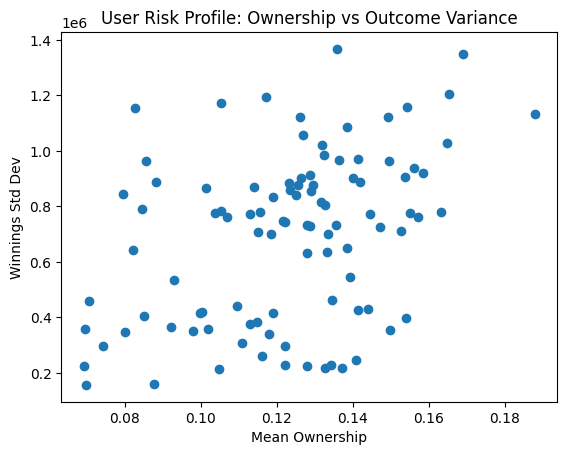

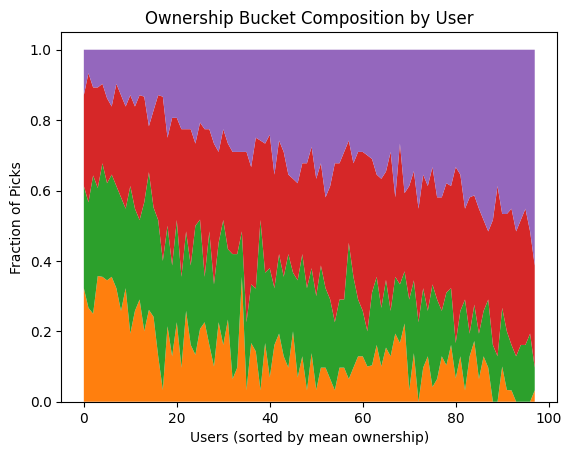

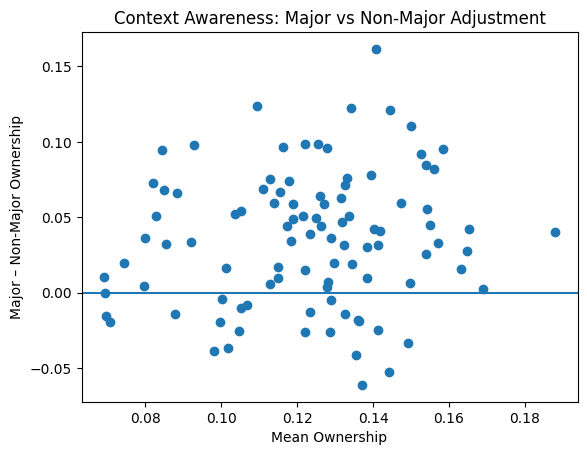

In [73]:
# ============================
# USER BEHAVIOR VISUALIZATION
# ============================

import matplotlib.pyplot as plt

# focus on small leagues combined (behavior matters more than season here)
uf = user_fingerprints.copy()

# ----------------------------
# 1) Mean ownership vs variance (risk profile)
# ----------------------------
plt.figure()
plt.scatter(
    uf["mean_ownership"],
    uf["winnings_std"],
)
plt.xlabel("Mean Ownership")
plt.ylabel("Winnings Std Dev")
plt.title("User Risk Profile: Ownership vs Outcome Variance")
plt.show()

# Interpretation:
# - top-left: low ownership, low variance (rare)
# - bottom-right: chalk grinders
# - top-right: emotional / undisciplined players


# ----------------------------
# 2) Ownership composition (stacked behavior)
# ----------------------------
# sort users by mean ownership for readability
uf_sorted = uf.sort_values("mean_ownership")

plt.figure()
plt.stackplot(
    range(len(uf_sorted)),
    uf_sorted["pct_0_1"],
    uf_sorted["pct_1_3"],
    uf_sorted["pct_3_7"],
    uf_sorted["pct_7_15"],
    uf_sorted["pct_15_plus"],
)
plt.xlabel("Users (sorted by mean ownership)")
plt.ylabel("Fraction of Picks")
plt.title("Ownership Bucket Composition by User")
plt.show()

# Interpretation:
# - left side: contrarians
# - right side: chalk-heavy
# - middle bands reveal disciplined optimizers


# ----------------------------
# 3) Major vs Non-Major adjustment
# ----------------------------
plt.figure()
plt.scatter(
    uf["mean_ownership"],
    uf["major_minus_non_major"],
)
plt.axhline(0)
plt.xlabel("Mean Ownership")
plt.ylabel("Major – Non-Major Ownership")
plt.title("Context Awareness: Major vs Non-Major Adjustment")
plt.show()

# Interpretation:
# - near 0: event-agnostic users
# - positive: chalk up at majors (GOOD)
# - negative: fade chalk at majors (BAD)

In [74]:
# ============================
# USER ARCHETYPES + PRESSURE INDEX
# ============================

uf = user_fingerprints.copy()

# league-level median std for emotional chalk definition
league_std = (
    uf.groupby(["league_key", "season"])["winnings_std"]
    .median()
    .rename("league_std_median")
    .reset_index()
)

uf = uf.merge(league_std, on=["league_key", "season"], how="left")

# ----------------------------
# Archetype assignment
# ----------------------------
def assign_archetype(r):
    if r["mean_ownership"] >= 0.15 and r["pct_15_plus"] >= 0.40:
        return "chalk_grinder"
    if r["mean_ownership"] >= 0.15 and r["winnings_std"] >= r["league_std_median"]:
        return "emotional_chalk"
    if r["mean_ownership"] <= 0.09 and (r["pct_0_1"] + r["pct_1_3"]) >= 0.40:
        return "serial_contrarian"
    if (
        0.11 <= r["mean_ownership"] <= 0.14
        and r["pct_7_15"] >= 0.35
        and r["major_minus_non_major"] >= 0.02
    ):
        return "disciplined_optimizer"
    return "event_agnostic"

uf["archetype"] = uf.apply(assign_archetype, axis=1)

# ----------------------------
# League-level archetype mix
# ----------------------------
league_mix = (
    uf.groupby(["league_key", "season", "archetype"])
    .size()
    .rename("users")
    .reset_index()
)

league_totals = (
    league_mix.groupby(["league_key", "season"])["users"]
    .sum()
    .rename("total_users")
    .reset_index()
)

league_mix = league_mix.merge(
    league_totals, on=["league_key", "season"], how="left"
)

league_mix["user_pct"] = league_mix["users"] / league_mix["total_users"]

# ----------------------------
# Pressure index
# ----------------------------
# weights reflect how much each group compresses ownership
pressure_weights = {
    "chalk_grinder": 1.0,
    "emotional_chalk": 0.6,
    "disciplined_optimizer": 0.8,
    "serial_contrarian": -0.3,
    "event_agnostic": 0.0,
}

league_mix["pressure_contrib"] = league_mix.apply(
    lambda r: pressure_weights.get(r["archetype"], 0) * r["user_pct"],
    axis=1,
)

league_pressure = (
    league_mix.groupby(["league_key", "season"])
    .agg(
        pressure_index=("pressure_contrib", "sum"),
        disciplined_share=("user_pct", lambda s: s[league_mix.loc[s.index, "archetype"] == "disciplined_optimizer"].sum()),
        chalk_share=("user_pct", lambda s: s[league_mix.loc[s.index, "archetype"].isin(["chalk_grinder", "emotional_chalk"])].sum()),
    )
    .reset_index()
)

league_pressure

,league_key,season,pressure_index,disciplined_share,chalk_share
0,2024_small,2024,0.200000,0.122449,0.102041
1,2025_small,2025,0.236735,0.102041,0.163265


In [75]:
# ============================
# WINNER TIERS (USER–SEASON)
# ============================

# aggregate total winnings per user-season
user_season = (
    leagues_all
    .groupby(["league_key", "season", "username"], as_index=False)
    .agg(
        total_winnings=("raw_winnings", "sum"),
        picks=("raw_winnings", "size"),
    )
)

# rank users within each league-season
user_season["rank"] = (
    user_season
    .groupby(["league_key", "season"])["total_winnings"]
    .rank(method="min", ascending=False)
)

user_season["field_size"] = (
    user_season
    .groupby(["league_key", "season"])["username"]
    .transform("count")
)

# winner tiers
user_season["pct_rank"] = user_season["rank"] / user_season["field_size"]

user_season["winner_tier"] = pd.cut(
    user_season["pct_rank"],
    bins=[0, 0.01, 0.03, 0.10, 1.0],
    labels=["top_1pct", "top_3pct", "top_10pct", "rest"],
    include_lowest=True,
)

user_season.sort_values(
    ["league_key", "season", "rank"]
).head(20)

,league_key,season,username,total_winnings,picks,rank,field_size,pct_rank,winner_tier
34,2024_small,2024,jtsalvetti,22148660.0,30,1.0,49,0.020408,top_3pct
10,2024_small,2024,JLUDEOBV,20554934.0,31,2.0,49,0.040816,top_10pct
45,2024_small,2024,thorrr,20021359.0,31,3.0,49,0.061224,top_10pct
31,2024_small,2024,joempike,19570800.0,31,4.0,49,0.081633,top_10pct
1,2024_small,2024,AKsREVENGE,17989977.0,31,5.0,49,0.102041,rest
32,2024_small,2024,jonescurtisw,17982655.0,31,6.0,49,0.122449,rest
7,2024_small,2024,Enicola0922,17277345.0,31,7.0,49,0.142857,rest
3,2024_small,2024,Bjrobins123,17026476.0,31,8.0,49,0.163265,rest
30,2024_small,2024,itsabucslife1,16911459.0,31,9.0,49,0.183673,rest
48,2024_small,2024,zjb23,16792428.0,31,10.0,49,0.204082,rest


In [83]:
# ============================
# LOAD ODDS (run once)
# ============================

import pandas as pd
import numpy as np
import re

odds_df = pd.read_excel("/Users/joshmacbook/python_projects/OAD/Data/in Use/Odds_and_Results.xlsx")

# Required columns check
need = {"event_id", "dg_id", "close_odds"}
missing = need - set(odds_df.columns)
if missing:
    raise ValueError(f"odds_df missing required columns: {sorted(missing)}. Columns: {odds_df.columns.tolist()}")

odds_df = odds_df[["event_id", "dg_id", "close_odds"]].copy()

# --- odds parsing helpers ---
def american_to_prob(a: float) -> float:
    # implied probability ignoring vig
    if a > 0:
        return 100.0 / (a + 100.0)
    else:
        return (-a) / ((-a) + 100.0)

def parse_close_odds_to_prob(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    # already numeric?
    try:
        v = float(s)
        # heuristic:
        # if v between 0 and 1 -> already prob
        if 0 < v < 1:
            return v
        # if v >= 1 and looks like decimal odds (e.g., 6.5)
        if v >= 1 and v < 200:  # decimal odds typically small
            return 1.0 / v
        # otherwise treat as American odds magnitude
        # common: 800, -110, 2500
        return american_to_prob(v)
    except Exception:
        pass

    # american with +/-
    m = re.match(r"^\s*([+-])\s*(\d+(\.\d+)?)\s*$", s)
    if m:
        sign = m.group(1)
        num = float(m.group(2))
        v = num if sign == "+" else -num
        return american_to_prob(v)

    # fractional odds like "8/1"
    m = re.match(r"^\s*(\d+(\.\d+)?)\s*/\s*(\d+(\.\d+)?)\s*$", s)
    if m:
        num = float(m.group(1))
        den = float(m.group(3))
        dec = 1.0 + (num / den)
        return 1.0 / dec

    return np.nan

odds_df["win_prob_est"] = odds_df["close_odds"].apply(parse_close_odds_to_prob)

# clean types
odds_df["event_id"] = pd.to_numeric(odds_df["event_id"], errors="coerce").astype("Int64")
odds_df["dg_id"] = pd.to_numeric(odds_df["dg_id"], errors="coerce").astype("Int64")
odds_df["win_prob_est"] = pd.to_numeric(odds_df["win_prob_est"], errors="coerce")

print("odds_df rows:", len(odds_df))
print("win_prob_est non-null:", int(odds_df["win_prob_est"].notna().sum()))
print("win_prob_est null:", int(odds_df["win_prob_est"].isna().sum()))
odds_df.head()

odds_df rows: 11990
win_prob_est non-null: 11990
win_prob_est null: 0


,event_id,dg_id,close_odds,win_prob_est
0,6,22833,501.0,0.166389
1,6,14609,51.0,0.019608
2,6,25363,91.0,0.010989
3,6,12423,101.0,0.009901
4,6,15756,301.0,0.249377


In [84]:
# ============================
# PICK-LEVEL DATASET (ownership + odds)
# ============================

picks = leagues_all.merge(
    ownership[["league_key", "season", "event_id", "dg_id", "ownership_pct"]],
    on=["league_key", "season", "event_id", "dg_id"],
    how="left",
)

picks = picks.merge(
    odds_df[["event_id", "dg_id", "win_prob_est"]],
    on=["event_id", "dg_id"],
    how="left",
)

# sanity checks (hard fail only on ownership; odds can have some missing)
if picks["ownership_pct"].isna().any():
    raise ValueError("Missing ownership_pct after merge (should never happen).")

missing_odds = int(picks["win_prob_est"].isna().sum())
print("Rows:", len(picks))
print("Missing win_prob_est rows:", missing_odds)

# optional: inspect a few missing odds rows
picks.loc[picks["win_prob_est"].isna(), ["league_key","season","event_id","dg_id","player_name"]].drop_duplicates().head(20)

Rows: 265287
Missing win_prob_est rows: 36879


,league_key,season,event_id,dg_id,player_name
773,2024_small,2024,480,23602,Nicolai Hojgaard
825,2024_small,2024,480,13412,Thorbjorn Olesen
1453,2024_small,2024,100,17365,Keith Mitchell
1479,2024_small,2024,100,7960,Luke List
1489,2024_small,2024,100,19396,Jake Knapp
1495,2024_small,2024,100,17266,Carl Yuan
1541,2024_small,2024,19,14577,Harris English
1542,2024_small,2024,19,23950,Ludvig Aberg
1546,2024_small,2024,19,26096,Akshay Bhatia
1550,2024_small,2024,19,12294,Tommy Fleetwood


In [85]:
# ============================
# AGGRESSION SCORES (PICK LEVEL) - FIXED
# ============================

# Ownership percentile within each league-event (lower ownership => more aggressive)
picks["ownership_rank_pct"] = (
    picks.groupby(["league_key", "season", "event_id"])["ownership_pct"]
    .rank(pct=True)
)

# Odds percentile within each event (lower win_prob => more aggressive)
# rank win_prob descending: best win_prob -> rank_pct near 0
picks["winprob_rank_pct"] = (
    picks.groupby(["event_id"])["win_prob_est"]
    .rank(ascending=False, pct=True)
)

picks["ownership_aggression"] = 1.0 - picks["ownership_rank_pct"]
picks["odds_aggression"] = picks["winprob_rank_pct"]

def total_aggression(row):
    # large league => weight ownership more
    if "large" in str(row["league_key"]):
        return 0.6 * row["ownership_aggression"] + 0.4 * row["odds_aggression"]
    # small leagues => weight performance risk more
    return 0.3 * row["ownership_aggression"] + 0.7 * row["odds_aggression"]

picks["total_aggression"] = picks.apply(total_aggression, axis=1)

picks[[
    "league_key","season","event_id","username",
    "ownership_pct","win_prob_est",
    "ownership_aggression","odds_aggression","total_aggression"
]].head(15)

,league_key,season,event_id,username,ownership_pct,win_prob_est,ownership_aggression,odds_aggression,total_aggression
0,2024_small,2024,11,9thGreenAtNine,0.040816,0.019608,0.839286,0.449992,0.566780
1,2024_small,2024,11,9thGreenAtNine,0.040816,0.019608,0.839286,0.449992,0.566780
2,2024_small,2024,11,9thGreenAtNine,0.040816,0.016393,0.839286,0.562927,0.645834
3,2024_small,2024,11,AKsREVENGE,0.183673,0.012346,0.425000,0.716209,0.628846
4,2024_small,2024,11,AKsREVENGE,0.183673,0.009901,0.425000,0.788097,0.679168
5,2024_small,2024,11,AKsREVENGE,0.183673,0.332226,0.425000,0.008108,0.133176
6,2024_small,2024,11,anpyanks,0.224490,0.016393,0.114286,0.562927,0.428334
7,2024_small,2024,11,anpyanks,0.224490,0.016393,0.114286,0.562927,0.428334
8,2024_small,2024,11,anpyanks,0.224490,0.017857,0.114286,0.495538,0.381163
9,2024_small,2024,11,balvari,0.061224,0.027778,0.725000,0.258729,0.398610


In [86]:
# ============================
# WINNER TIERS (USER–SEASON)
# ============================

user_season = (
    leagues_all
    .groupby(["league_key", "season", "username"], as_index=False)
    .agg(
        total_winnings=("raw_winnings", "sum"),
        picks=("raw_winnings", "size"),
    )
)

user_season["rank"] = (
    user_season
    .groupby(["league_key", "season"])["total_winnings"]
    .rank(method="min", ascending=False)
)

user_season["field_size"] = (
    user_season
    .groupby(["league_key", "season"])["username"]
    .transform("count")
)

user_season["pct_rank"] = user_season["rank"] / user_season["field_size"]

user_season["winner_tier"] = pd.cut(
    user_season["pct_rank"],
    bins=[0, 0.01, 0.03, 0.10, 1.0],
    labels=["top_1pct", "top_3pct", "top_10pct", "rest"],
    include_lowest=True,
)

In [87]:
# ============================
# AGGRESSION BY USER-SEASON + TIER SUMMARY
# ============================

user_aggression = (
    picks
    .groupby(["league_key", "season", "username"], as_index=False)
    .agg(
        mean_ownership_aggr=("ownership_aggression", "mean"),
        mean_odds_aggr=("odds_aggression", "mean"),
        mean_total_aggr=("total_aggression", "mean"),
    )
)

user_aggression = user_aggression.merge(
    user_season[["league_key","season","username","winner_tier"]],
    on=["league_key","season","username"],
    how="left",
)

winner_aggr_summary = (
    user_aggression
    .groupby(["league_key","season","winner_tier"])
    .agg(
        users=("mean_total_aggr","size"),
        avg_total_aggr=("mean_total_aggr","mean"),
        avg_ownership_aggr=("mean_ownership_aggr","mean"),
        avg_odds_aggr=("mean_odds_aggr","mean"),
    )
    .reset_index()
    .sort_values(["league_key","season","winner_tier"])
)

winner_aggr_summary

,league_key,season,winner_tier,users,avg_total_aggr,avg_ownership_aggr,avg_odds_aggr
0,2024_small,2024,top_1pct,0,NaN,NaN,NaN
1,2024_small,2024,top_3pct,1,0.453622,0.490544,0.434231
2,2024_small,2024,top_10pct,3,0.463279,0.441735,0.470302
3,2024_small,2024,rest,45,0.466703,0.499329,0.452520
4,2024_small,2025,top_1pct,0,NaN,NaN,NaN
5,2024_small,2025,top_3pct,0,NaN,NaN,NaN
6,2024_small,2025,top_10pct,0,NaN,NaN,NaN
7,2024_small,2025,rest,0,NaN,NaN,NaN
8,2025_large,2024,top_1pct,0,NaN,NaN,NaN
9,2025_large,2024,top_3pct,0,NaN,NaN,NaN


In [88]:
# Odds coverage sanity
print("odds_df rows:", len(odds_df))
print("win_prob_est non-null:", int(odds_df["win_prob_est"].notna().sum()))
print("win_prob_est null:", int(odds_df["win_prob_est"].isna().sum()))

# Picks odds coverage sanity
print("picks rows:", len(picks))
print("picks win_prob_est non-null:", int(picks["win_prob_est"].notna().sum()))
print("picks win_prob_est null:", int(picks["win_prob_est"].isna().sum()))

# If missing exists, see which events / names are missing (top 15)
if picks["win_prob_est"].isna().any():
    miss = (
        picks.loc[picks["win_prob_est"].isna(), ["league_key","season","event_id","event_name","dg_id","player_name"]]
        .drop_duplicates()
    )
    print("Distinct missing (event_id, dg_id) pairs:", len(miss))
    display(miss.head(15))


odds_df rows: 11990
win_prob_est non-null: 11990
win_prob_est null: 0
picks rows: 265287
picks win_prob_est non-null: 228408
picks win_prob_est null: 36879
Distinct missing (event_id, dg_id) pairs: 631


,league_key,season,event_id,event_name,dg_id,player_name
773,2024_small,2024,480,Mexico Open at Vidanta,23602,Nicolai Hojgaard
825,2024_small,2024,480,Mexico Open at Vidanta,13412,Thorbjorn Olesen
1453,2024_small,2024,100,Texas Children's Houston Open,17365,Keith Mitchell
1479,2024_small,2024,100,Texas Children's Houston Open,7960,Luke List
1489,2024_small,2024,100,Texas Children's Houston Open,19396,Jake Knapp
1495,2024_small,2024,100,Texas Children's Houston Open,17266,Carl Yuan
1541,2024_small,2024,19,Valero Texas Open,14577,Harris English
1542,2024_small,2024,19,Valero Texas Open,23950,Ludvig Aberg
1546,2024_small,2024,19,Valero Texas Open,26096,Akshay Bhatia
1550,2024_small,2024,19,Valero Texas Open,12294,Tommy Fleetwood


In [89]:
# Robust odds rank pct: only where win_prob_est exists
picks["ownership_rank_pct"] = (
    picks.groupby(["league_key","season","event_id"])["ownership_pct"].rank(pct=True)
)
picks["ownership_aggression"] = 1.0 - picks["ownership_rank_pct"]

picks["winprob_rank_pct"] = (
    picks.groupby(["event_id"])["win_prob_est"].rank(ascending=False, pct=True)
)
picks["odds_aggression"] = picks["winprob_rank_pct"]

def total_aggression_robust(row):
    # choose weights by league type
    if "large" in str(row["league_key"]):
        w_own, w_odds = 0.6, 0.4
    else:
        w_own, w_odds = 0.3, 0.7

    # if odds missing, fall back to ownership only (renormalize)
    if pd.isna(row["odds_aggression"]):
        return row["ownership_aggression"]

    return w_own * row["ownership_aggression"] + w_odds * row["odds_aggression"]

picks["total_aggression"] = picks.apply(total_aggression_robust, axis=1)

print("odds_aggression missing:", int(picks["odds_aggression"].isna().sum()))

odds_aggression missing: 36879


In [90]:
# Build user_aggression (unchanged)
user_aggression = (
    picks
    .groupby(["league_key","season","username"], as_index=False)
    .agg(
        mean_ownership_aggr=("ownership_aggression", "mean"),
        mean_odds_aggr=("odds_aggression", "mean"),          # may be NaN if all missing (unlikely)
        mean_total_aggr=("total_aggression", "mean"),
        picks=("dg_id", "size"),
        odds_missing=("odds_aggression", lambda s: int(s.isna().sum())),
    )
)

user_aggression = user_aggression.merge(
    user_season[["league_key","season","username","winner_tier"]],
    on=["league_key","season","username"],
    how="left",
)

winner_aggr_summary = (
    user_aggression
    .groupby(["league_key","season","winner_tier"], dropna=False)
    .agg(
        users=("username","size"),
        avg_total_aggr=("mean_total_aggr","mean"),
        avg_ownership_aggr=("mean_ownership_aggr","mean"),
        avg_odds_aggr=("mean_odds_aggr","mean"),
        avg_odds_missing=("odds_missing","mean"),
    )
    .reset_index()
    .sort_values(["league_key","season","winner_tier"])
)

winner_aggr_summary


,league_key,season,winner_tier,users,avg_total_aggr,avg_ownership_aggr,avg_odds_aggr,avg_odds_missing
0,2024_small,2024,top_1pct,0,NaN,NaN,NaN,NaN
1,2024_small,2024,top_3pct,1,0.451433,0.490544,0.434231,8.000000
2,2024_small,2024,top_10pct,3,0.457054,0.441735,0.470302,7.000000
3,2024_small,2024,rest,45,0.469922,0.499329,0.452520,7.288889
4,2024_small,2025,top_1pct,0,NaN,NaN,NaN,NaN
5,2024_small,2025,top_3pct,0,NaN,NaN,NaN,NaN
6,2024_small,2025,top_10pct,0,NaN,NaN,NaN,NaN
7,2024_small,2025,rest,0,NaN,NaN,NaN,NaN
8,2025_large,2024,top_1pct,0,NaN,NaN,NaN,NaN
9,2025_large,2024,top_3pct,0,NaN,NaN,NaN,NaN


In [92]:
# ============================
# RUNNING SEASON AGGRESSION (PER USER)
# ============================

# This expects:
# - picks has: league_key, season, username, event_id, event_date, total_aggression,
#             ownership_aggression, odds_aggression
# If event_date isn't in picks, we merge it from leagues_all.

need_cols = {"league_key","season","username","event_id","total_aggression","ownership_aggression","odds_aggression"}
missing = need_cols - set(picks.columns)
if missing:
    raise ValueError(f"picks missing required columns: {sorted(missing)}")

# ensure event_date exists
if "event_date" not in picks.columns:
    event_dates = leagues_all[["league_key","season","event_id","event_date"]].drop_duplicates()
    picks = picks.merge(event_dates, on=["league_key","season","event_id"], how="left")

if picks["event_date"].isna().any():
    raise ValueError("Some picks missing event_date after merge; cannot compute running order cleanly.")

p = picks.copy()
p["event_date"] = pd.to_datetime(p["event_date"], errors="coerce")
p = p.sort_values(["league_key","season","username","event_date","event_id"])

# cumulative means
p["cum_picks"] = p.groupby(["league_key","season","username"]).cumcount() + 1

p["cum_total_aggr"] = (
    p.groupby(["league_key","season","username"])["total_aggression"]
    .expanding()
    .mean()
    .reset_index(level=[0,1,2], drop=True)
)

p["cum_own_aggr"] = (
    p.groupby(["league_key","season","username"])["ownership_aggression"]
    .expanding()
    .mean()
    .reset_index(level=[0,1,2], drop=True)
)

# odds aggression may have NaN (missing odds); use expanding mean over available odds only
p["cum_odds_aggr"] = (
    p.groupby(["league_key","season","username"])["odds_aggression"]
    .expanding()
    .mean()
    .reset_index(level=[0,1,2], drop=True)
)

# ----------------------------
# Apply league-type bands (FIXED)
# ----------------------------
is_large = p["league_key"].astype(str).str.contains("large", case=False, na=False)

p["soft_lo"] = np.where(is_large, 0.49, 0.44)
p["soft_hi"] = np.where(is_large, 0.52, 0.50)
p["hard_lo"] = np.where(is_large, 0.47, 0.42)
p["hard_hi"] = np.where(is_large, 0.54, 0.52)

p["outside_soft_band"] = (p["cum_total_aggr"] < p["soft_lo"]) | (p["cum_total_aggr"] > p["soft_hi"])
p["outside_hard_band"] = (p["cum_total_aggr"] < p["hard_lo"]) | (p["cum_total_aggr"] > p["hard_hi"])

# output: latest running state per user (for dashboard summary)
running_latest = (
    p.sort_values(["league_key","season","username","event_date","event_id"])
     .groupby(["league_key","season","username"], as_index=False)
     .tail(1)
     .loc[:, [
         "league_key","season","username",
         "cum_picks","cum_total_aggr","cum_own_aggr","cum_odds_aggr",
         "outside_soft_band","outside_hard_band"
     ]]
     .sort_values(["league_key","season","cum_total_aggr"], ascending=[True, True, False])
     .reset_index(drop=True)
)

running_latest.head(25)


,league_key,season,username,cum_picks,cum_total_aggr,cum_own_aggr,cum_odds_aggr,outside_soft_band,outside_hard_band
0,2024_small,2024,zjb23,60,0.577424,0.643815,0.526882,True,True
1,2024_small,2024,josen1,57,0.552687,0.632117,0.497614,True,True
2,2024_small,2024,logandempsey20,40,0.546754,0.579839,0.537678,True,True
3,2024_small,2024,Pitch12,73,0.533798,0.622141,0.478445,True,True
4,2024_small,2024,halliam1114,65,0.533357,0.626469,0.490638,True,True
5,2024_small,2024,pbyrne11,63,0.532289,0.564180,0.492008,True,True
6,2024_small,2024,chrismurf21,63,0.527525,0.616820,0.504299,True,True
7,2024_small,2024,JermRussLFG,55,0.526814,0.512037,0.537233,True,True
8,2024_small,2024,one007,61,0.518663,0.612009,0.476407,True,False
9,2024_small,2024,Skibasher,52,0.517295,0.613923,0.451603,True,False
